This notebook is to develop code for a case study for an undisclosed company in Adtech
- Date: July 21st, 2026

You are tasked with preparing a presentation for a long-time client, Agency XYZ, regarding a recent digital ad campaign for City XYZ. You will need to cover:
 - Programmatic Ad-Tech Landscape: An overview of the programmatic space, key players, and [REDACTED]’s value as a Demand-Side Platform.
 - Campaign Analysis: A data-driven review of campaign performance, including insights on what is working and recommendations for future strategies. Please perform your analysis using SQL or Python and include your documented code as part of the submission.
 - Product Strategy & Critical Thinking: Strategic considerations regarding a travel-specific identity data graph, including potential data sources, use cases for targeting and measurement, and risk mitigation strategies.


Expectations & Evaluation
We are looking to see how you approach problems and your ability to turn complex data and concepts into clear, actionable insights. We will be evaluating your submission on the following criteria:
 - Communication: Your ability to synthesize complex concepts into easy-to-understand terms.
 - Technical & Strategic Depth: For the ad-tech section, we look for a depth of industry analysis that goes beyond a surface-level understanding. For the campaign analysis, we assess your technical data capabilities and the quality of your business insights.
 - Innovative Thinking: Your ability to align feature recommendations with macro/industry trends and provide thoughtful risk mitigation strategies.


Submission Guidelines
 - Format: Please provide a summary presentation (maximum 6 slides, excluding cover page/appendices). 
 - Code Submission: As part of your campaign analysis, please include your documented SQL or Python code. We want to see the logic and technical steps you took to arrive at your insights.



# Setup
## Requirements, Imports

In [514]:
!pip install -r ../requirements.txt
# this installs the following: 
    # pandas
    # matplotlib
    # numpy
    # seaborn
    # scipy
    # scikit-learn
    # openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [515]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import sklearn
import seaborn as sns
import scipy
from scipy import stats

## Load in data

In [516]:
visitationFTA = pd.read_excel("../data/CityXYZ_visitationFTA_data_March.xlsx")
visitationFTA.head()
# note: FTA = Foot Traffic Attribution. This dataset shows real customers that came into a store, and how we can attribute their visit!

,Visit,Advertiser ID,User Profile ID,Spatial Location ID,Visit Time Stamp,Visit Attribute Score,Location Type,Visited ZIP,New Visit,Attributed Visit,...,Demo HHI,Origin_Country,Origin_Region,Origin_DMA,Origin_City,Origin_Zipcode,Visit Date,Campaign Name,Creative Name,Group
0,1,1234,07502db2-a8cb-4c1d-9ddf-9a47f75ea747,1276102952747384832,1743187567,0.952575,Attractions,89052,0,True,...,$100-$150K,us,nv,839,henderson,89044,28/03/2025,AgencyXYZ_Display_Travel AI _CompetitorConques...,484343_V1_160x600_SB_44099_Las_City XYZ,Exposed
1,2,1234,a62bf21b-bdb2-4b25-977c-2492a2ed9f34,1276102959519739904,1742764148,0.952222,Retail,89141,0,True,...,$75-100K,us,fl,528,ft lauderdale,33322,23/03/2025,AgencyXYZ_Native_Travel AI_City XYZ Not Booked,BRL - 1200x627,Exposed
2,3,1234,238a7097-5f88-4758-a526-298d9d7730b9,1276102959519739904,1742068105,0.950136,Retail,89141,0,True,...,$100-$150K,us,ok,671,bixby,74008,15/03/2025,AgencyXYZ_Native_Travel AI_City XYZ Booked,BRL - 1200x627,Exposed
3,4,1234,43f649f7-8859-4d16-a2fc-644db8feb5ef,699463065495220224,1743195529,0.948397,Attractions,89124,1,True,...,$75-100K,us,mi,505,new baltimore,48047,28/03/2025,AgencyXYZ_Native_Travel AI_City XYZ Booked,NMC1 Homepage - 800x600,Exposed
4,5,1234,84b3fff2-8400-412b-a75b-cdc7be607260,699463065495220224,1743026081,0.948396,Attractions,89124,1,True,...,$100-$150K,us,ca,862,orangevale,95662,26/03/2025,AgencyXYZ_Display_Travel AI _CompetitorConques...,484343_V1_728x90_SB_44099_Las_City XYZ,Exposed


In [517]:
campaign_metrics = pd.read_excel("../data/CityXYZ_CampaignMetrics_March.xlsx")
campaign_metrics.head()

,Advertiser ID,Advertiser,Campaign Group ID,Campaign Group,Campaign ID,Campaign,Targeting Solution Used,Browsing Behaviour Targeted,Booked to City XYZ last year,Creative ID,Creative,Creative Size,Channel Type,Channel Subtype,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546648,NMC1 Homepage - 1200x627,1200x627,Native,Standard,610.64,79370,45,7.69,0.0006,13.57
1,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546649,NMC1 Homepage - 600x600,600x600,Native,Standard,65.83,8308,4,7.92,0.0005,16.46
2,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546650,NMC1 Homepage - 800x600,800x600,Native,Standard,24.83,3256,0,7.63,0.0000,0.00
3,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546651,BRL - 1200x627,1200x627,Native,Standard,393.53,51281,27,7.67,0.0005,14.58
4,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546652,BRL - 600x600,600x600,Native,Standard,75.31,9557,4,7.88,0.0004,18.83


In [518]:
dataframe_names = {
    "Visitation FTA"    : visitationFTA,
    "Campaign Metrics"  : campaign_metrics,
}
for name, dataframe in dataframe_names.items():
    print(f"\nFor the dataset {name}, here is the info:")
    dataframe.info()


For the dataset Visitation FTA, here is the info:
<class 'pandas.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Visit                  2303 non-null   int64  
 1   Advertiser ID          2303 non-null   int64  
 2   User Profile ID        2303 non-null   str    
 3   Spatial Location ID    2303 non-null   int64  
 4   Visit Time Stamp       2303 non-null   int64  
 5   Visit Attribute Score  2303 non-null   float64
 6   Location Type          2303 non-null   str    
 7   Visited ZIP            2303 non-null   int64  
 8   New Visit              2303 non-null   int64  
 9   Attributed Visit       2303 non-null   bool   
 10  Campaign ID            2303 non-null   int64  
 11  Creative ID            2303 non-null   int64  
 12  Auction ID             2303 non-null   str    
 13  First Impression Date  2303 non-null   str    
 14  Device Type     

In [519]:
visitationFTA.describe()

,Visit,Advertiser ID,Spatial Location ID,Visit Time Stamp,Visit Attribute Score,Visited ZIP,New Visit,Campaign ID,Creative ID,Total Impressions,Origin_DMA
count,2303.000000,2303.0,2.303000e+03,2.303000e+03,2303.000000,2303.000000,2303.000000,2.303000e+03,2.303000e+03,2303.000000,2303.000000
mean,1152.000000,1234.0,4.258054e+17,1.742814e+09,0.915715,89109.283543,0.649153,2.244842e+06,9.546698e+06,7.328267,713.461138
std,664.963157,0.0,3.436973e+17,4.400115e+05,0.001618,8.715850,0.477339,2.872344e+01,2.672137e+01,19.248138,119.554651
min,1.000000,1234.0,1.229956e+17,1.741686e+09,0.915618,89014.000000,0.000000,2.244711e+06,9.546648e+06,1.000000,0.000000
25%,576.500000,1234.0,1.231836e+17,1.742500e+09,0.915628,89109.000000,0.000000,2.244830e+06,9.546678e+06,1.500000,613.000000
50%,1152.000000,1234.0,1.231844e+17,1.742871e+09,0.915633,89109.000000,1.000000,2.244857e+06,9.546690e+06,3.000000,753.000000
75%,1727.500000,1234.0,6.996451e+17,1.743187e+09,0.915650,89109.000000,1.000000,2.244861e+06,9.546724e+06,8.000000,807.000000
max,2303.000000,1234.0,1.276106e+18,1.743465e+09,0.952575,89169.000000,1.000000,2.244863e+06,9.546744e+06,494.000000,881.000000


In [520]:
campaign_metrics.describe()

,Advertiser ID,Campaign Group ID,Campaign ID,Creative ID,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
count,120.0,120.0,1.200000e+02,1.200000e+02,120.000000,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,1234.0,339812.0,2.244833e+06,9.599958e+06,833.335917,1.598628e+05,288.075000,5.944667,0.001622,9.608417
std,0.0,0.0,3.395613e+01,1.077439e+05,1424.737128,2.975639e+05,600.932387,1.302939,0.002317,12.823191
min,1234.0,339812.0,2.244711e+06,9.546648e+06,0.220000,3.100000e+01,0.000000,3.900000,0.000000,0.000000
25%,1234.0,339812.0,2.244829e+06,9.546678e+06,71.157500,1.021800e+04,6.500000,4.955000,0.000400,2.205000
50%,1234.0,339812.0,2.244832e+06,9.546708e+06,266.990000,4.747600e+04,36.000000,6.005000,0.001300,3.485000
75%,1234.0,339812.0,2.244858e+06,9.546738e+06,889.840000,1.566270e+05,273.000000,7.047500,0.002100,12.310000
max,1234.0,339812.0,2.244863e+06,9.877153e+06,6620.860000,1.618553e+06,3070.000000,9.740000,0.017600,73.040000


# Preprocess Data
## Data cleaning
### Null values

In [521]:
# As seen above in the .info prints, both datasets have no nulls, but to check this, I like to visualize with a heatmap.
# Here, any null values in the datasets would be colored differently than red, but they are all the same, showing no null data:

<Axes: >

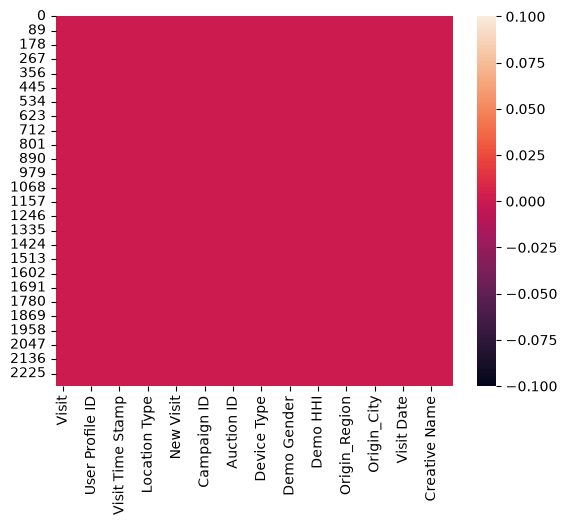

In [522]:
sns.heatmap(visitationFTA.isnull())

<Axes: >

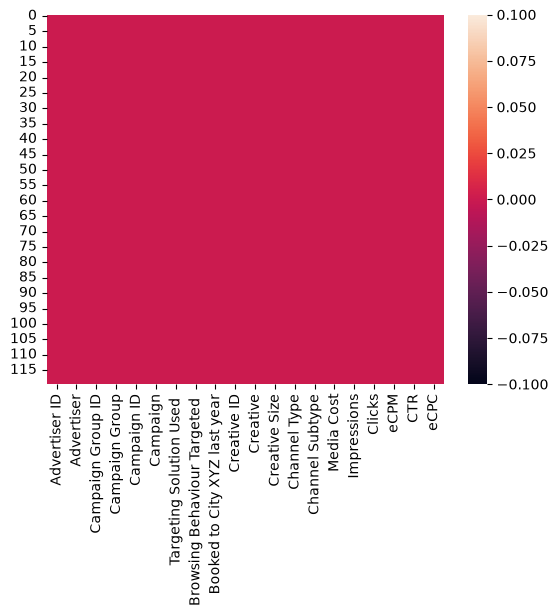

In [523]:
sns.heatmap(campaign_metrics.isnull())

### Duplicates

In [524]:
for df in [visitationFTA, campaign_metrics]:
    numBefore = df.shape[0]
    df.drop_duplicates()
    print(f"Cleaned from {numBefore} to {df.shape[0]} rows.")

Cleaned from 2303 to 2303 rows.
Cleaned from 120 to 120 rows.


In [525]:
# so there aren't any clear duplicates, but there still might be data with the same key column ID, that is duplicated.
# By looking at the dfs, I see that:
    # visitationFTA 's key column is "Visit". and this is a unique identifier from 1 to 2303
    # campaign_metrics 's key column is "Creative ID". and this is a unique identifier from 9546648 to 9877153
        # Note, finding the keyCol for campaign_metrics was more involved:

# campaign_metrics['Advertiser ID'].value_counts()   # 1 unique value = all are identical, this column can be removed from this current analysis with no impact!
# campaign_metrics['Campaign ID'].value_counts()     # 16 unique values, not a keyCol
campaign_metrics['Creative ID'].value_counts()       # 120 unique values, this is the key idenitfier!
# campaign_metrics.head()

Creative ID
9546648    1
9546649    1
9546650    1
9546651    1
9546652    1
          ..
9800187    1
9877150    1
9877151    1
9877152    1
9877153    1
Name: count, Length: 120, dtype: int64

In [526]:
# visitationFTA.set_index('Visit', inplace = True)
# visitationFTA.head(1)

In [527]:
# campaign_metrics.set_index('Creative ID', inplace = True)
# campaign_metrics.head(1)

### Remove Static Columns
- To tidy up, we can remove columns that are entirely the same throughout the df. For example, I saw this:
- `campaign_metrics['Advertiser ID'].value_counts()` = 1 unique value 
- This means that the whole column is identical, this column can be removed from this current analysis with no impact!


In [528]:
def removeStaticCols (df, title):
    print (f"For dataframe {title}")
    retDf = df.copy()
    for col in retDf.columns:
        if retDf[col].nunique() == 1:
                    print(f"   Dropping '{col}' - only 1 unique value: {retDf[col].iloc[0]}")
                    retDf = retDf.drop(columns=[col])
    return retDf

visitationFTA = removeStaticCols(visitationFTA, "Visitation FTA")
campaign_metrics = removeStaticCols(campaign_metrics, "Campaign Metrics")
print(f"   No columns have been dropped.")


For dataframe Visitation FTA
   Dropping 'Advertiser ID' - only 1 unique value: 1234
   Dropping 'Attributed Visit' - only 1 unique value: True
   Dropping 'Origin_Country' - only 1 unique value: us
   Dropping 'Group' - only 1 unique value: Exposed
For dataframe Campaign Metrics
   Dropping 'Advertiser ID' - only 1 unique value: 1234
   Dropping 'Advertiser' - only 1 unique value: Agency XYZ
   Dropping 'Campaign Group ID' - only 1 unique value: 339812
   Dropping 'Campaign Group' - only 1 unique value: AgencyXYZ
   Dropping 'Channel Subtype' - only 1 unique value: Standard
   No columns have been dropped.


### Check Data Logic
#### Checking non-negatives
 - Some data can never be negative, like spend, or inventory, so I have to check this:

In [529]:
visitationFTA.columns

Index(['Visit', 'User Profile ID', 'Spatial Location ID', 'Visit Time Stamp',
       'Visit Attribute Score', 'Location Type', 'Visited ZIP', 'New Visit',
       'Campaign ID', 'Creative ID', 'Auction ID', 'First Impression Date',
       'Device Type', 'Total Impressions', 'Demo Gender', 'Demo Age',
       'Demo HHI', 'Origin_Region', 'Origin_DMA', 'Origin_City',
       'Origin_Zipcode', 'Visit Date', 'Campaign Name', 'Creative Name'],
      dtype='str')

In [530]:
visitationNumericCols = visitationFTA.select_dtypes(include="number")
visitationNumericCols.head(1)

,Visit,Spatial Location ID,Visit Time Stamp,Visit Attribute Score,Visited ZIP,New Visit,Campaign ID,Creative ID,Total Impressions,Origin_DMA
0,1,1276102952747384832,1743187567,0.952575,89052,0,2244831,9546733,1,839


In [531]:
listNonNegativeVisitation = ['Total Impressions']

In [532]:
campaign_metrics.columns

Index(['Campaign ID', 'Campaign', 'Targeting Solution Used ',
       'Browsing Behaviour Targeted ', 'Booked to City XYZ last year',
       'Creative ID', 'Creative', 'Creative Size', 'Channel Type',
       'Media Cost', 'Impressions', 'Clicks', 'eCPM', 'CTR', 'eCPC'],
      dtype='str')

In [533]:
campaignNumericCols = campaign_metrics.select_dtypes(include="number")
campaignNumericCols.head(1)

,Campaign ID,Creative ID,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,2244856,9546648,610.64,79370,45,7.69,0.0006,13.57


In [534]:
listNonNegativeCampaign = ['Media Cost', 'Impressions', 'Clicks', 'eCPM', 'CTR', 'eCPC']

In [535]:
def checkNegativeVisitation (df):
    retDf = df.copy()
    for col in listNonNegativeVisitation:
        negative_rows = df.loc[df[col] < 0]
        print(f"# of negative rows in Visitation FTA dataset:{negative_rows.shape[0]}")

checkNegativeVisitation(visitationFTA)

def checkNegativeCampaign (df):
    retDf = df.copy()
    for col in listNonNegativeCampaign:
        negative_rows = df.loc[df[col] < 0]
        print(f"# of negative rows in Campaign Metrics dataset:{negative_rows.shape[0]}")

checkNegativeCampaign(campaign_metrics)


# of negative rows in Visitation FTA dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0


- note, this code was not optimal, but it works, and shows no negative values.

#### Checking Categorical data


- Here what I am doing is to examine the categorical data columns. 
- Often data gets mislabelled, either with typos, case-sensitive differences, or mismatched formatting like added whitespace. 
- For my past analysis, I love using df.value_counts(), as it cleanly lays out how often different values appear in the dataset, so it is easy to spot errors.

In [536]:
visitationFTA.head(1)

,Visit,User Profile ID,Spatial Location ID,Visit Time Stamp,Visit Attribute Score,Location Type,Visited ZIP,New Visit,Campaign ID,Creative ID,...,Demo Gender,Demo Age,Demo HHI,Origin_Region,Origin_DMA,Origin_City,Origin_Zipcode,Visit Date,Campaign Name,Creative Name
0,1,07502db2-a8cb-4c1d-9ddf-9a47f75ea747,1276102952747384832,1743187567,0.952575,Attractions,89052,0,2244831,9546733,...,Female,45-54,$100-$150K,nv,839,henderson,89044,28/03/2025,AgencyXYZ_Display_Travel AI _CompetitorConques...,484343_V1_160x600_SB_44099_Las_City XYZ


In [537]:
categorical_cols_FTA = ['Device Type', 'Demo Gender', 'Demo Age', 'Demo HHI', 'Location Type', 'Origin_City']
visitationFTA_categorical = visitationFTA[categorical_cols_FTA]

visitationFTA_categorical.head(2)

,Device Type,Demo Gender,Demo Age,Demo HHI,Location Type,Origin_City
0,desktop,Female,45-54,$100-$150K,Attractions,henderson
1,mobile-web,Female,35-44,$75-100K,Retail,ft lauderdale


In [538]:
visitationFTA_categorical['Device Type'].value_counts()

Device Type
mobile-web    1627
mobile-app     307
desktop        183
tablet-app     122
tablet-web      64
Name: count, dtype: int64

In [539]:
visitationFTA_categorical['Demo Gender'].value_counts()

Demo Gender
Female    1276
Male      1027
Name: count, dtype: int64

In [540]:
visitationFTA_categorical['Demo Age'].value_counts()

Demo Age
25-34    608
55-64    426
65+      390
45-54    337
35-44    327
18-24    215
Name: count, dtype: int64

In [541]:
visitationFTA_categorical['Demo HHI'].value_counts()

Demo HHI
$75-100K      1150
$100-$150K     955
$150-250K      130
$250K+          68
Name: count, dtype: int64

In [542]:
visitationFTA_categorical['Location Type'].value_counts()

Location Type
Downtown Harbour                                                                799
Attractions                                                                     765
Retail                                                                          452
Car Rentals                                                                      94
Dining (_CompetitorConquesting fast food, coffee shops, desserts, smoothies)     62
Casinos                                                                          46
Restaurant and Dinning                                                           45
Hotels and Motels                                                                20
Recreation and Entertainment                                                     13
Spas                                                                              5
QSRs                                                                              2
Name: count, dtype: int64

In [543]:
visitationFTA_categorical['Origin_City'].value_counts()

Origin_City
las vegas     234
henderson      73
sacramento     41
phoenix        38
chicago        34
             ... 
boulder         1
renton          1
rawlins         1
lander          1
irmo            1
Name: count, Length: 722, dtype: int64

- Visitations FTA seems to have consistent Categoricals, no misspellings or errors in the data, causing data loss, which is great!
- Now to check the second dataset, Campaign Metrics!

In [544]:
campaign_metrics.head(1)

,Campaign ID,Campaign,Targeting Solution Used,Browsing Behaviour Targeted,Booked to City XYZ last year,Creative ID,Creative,Creative Size,Channel Type,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546648,NMC1 Homepage - 1200x627,1200x627,Native,610.64,79370,45,7.69,0.0006,13.57


In [545]:
categorical_cols_metrics = ['Targeting Solution Used ','Browsing Behaviour Targeted ', 'Booked to City XYZ last year', 'Channel Type']
campaign_categorical = campaign_metrics[categorical_cols_metrics]

campaign_categorical.head(2)

,Targeting Solution Used,Browsing Behaviour Targeted,Booked to City XYZ last year,Channel Type
0,PCAI,City XYZ interest,Booked,Native
1,PCAI,City XYZ interest,Booked,Native


In [546]:
campaign_categorical['Targeting Solution Used '].value_counts()

Targeting Solution Used 
Travel AI Audiences    72
PCAI                   48
Name: count, dtype: int64

In [547]:
campaign_categorical['Browsing Behaviour Targeted '].value_counts()

Browsing Behaviour Targeted 
City XYZ interest           60
Competitor City Interest    60
Name: count, dtype: int64

In [548]:
campaign_categorical['Booked to City XYZ last year'].value_counts()

Booked to City XYZ last year
Booked        60
Not Booked    60
Name: count, dtype: int64

In [549]:
campaign_categorical['Channel Type'].value_counts()

Channel Type
Display    72
Native     48
Name: count, dtype: int64

- It seems there is no missed categorical data in either dataset, which is great! 

#### Checking calculated values
- CPC: Cost per Click = Spend/Click
- eCPM: effective Cost per Mille (1000) = 1000*Spend/Impressions
- CTR: Clickthrough Rate = Clicks/Impressions
- eCPC: effective Cost per Click = total earning/total clicks

In [550]:
checking_metrics = campaign_metrics.copy()
colsToSkip = ['Media Cost','Impressions','Clicks','eCPM','CTR','eCPC']
for col in checking_metrics.columns:
    if col in colsToSkip: 
        pass
    else: 
        del checking_metrics[col]
checking_metrics.head(1)

,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,610.64,79370,45,7.69,0.0006,13.57


In [551]:
checking_metrics['Calculated eCPM'] = (checking_metrics['Media Cost'] / checking_metrics['Impressions'] * 1000).round(2)
checking_metrics['Calculated CTR'] = (checking_metrics['Clicks'] / checking_metrics['Impressions']).round(4)
checking_metrics['Calculated eCPC'] = (checking_metrics['Media Cost'] / checking_metrics['Clicks']).round(2)

checking_metrics.head(1)

,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC,Calculated eCPM,Calculated CTR,Calculated eCPC
0,610.64,79370,45,7.69,0.0006,13.57,7.69,0.0006,13.57


In [552]:
def checkCalculatedMetrics(df):
    retDf = df.copy()
    for col in ['eCPM', 'CTR', 'eCPC']:
        calc_col = 'Calculated ' + col
        abs_diff = np.abs(retDf[col] - retDf[calc_col])
        sum_abs_diff = abs_diff.sum()
        scale = np.abs(retDf[calc_col]).replace(0, np.nan)
        pct_off = (abs_diff / scale).replace([np.inf, -np.inf], np.nan)
        avg_pct_off = pct_off.mean(skipna=True) * 100
        print(f"- {col}:\tSum of differences = {sum_abs_diff:.4f}, Average % off = {avg_pct_off:.4f}%")
        if pct_off.isna().any():
            print(f"   Note: {pct_off.isna().sum()} rows had zero/undefined calculated {col}")

checkCalculatedMetrics(checking_metrics)

- eCPM:	Sum of differences = 0.3900, Average % off = 0.0525%
- CTR:	Sum of differences = 0.0008, Average % off = 2.2519%
   Note: 10 rows had zero/undefined calculated CTR
- eCPC:	Sum of differences = inf, Average % off = 0.0123%
   Note: 10 rows had zero/undefined calculated eCPC


- Note, it seems the metrics provided are great, and not too far off from what i was calculating, so moving forward, I will be simply using the metrics provided.

# Join data

## Prep for Joining Data
- Before blindly joining the 2 datasets, I gotta check if the granularity of the 2 datasets matches, and so how to organize the JOIN.
- Both dfs have `Campaign ID`, and `Creative ID` so we have 2 columns to check, to see which is our key column

### Campaign IDs
#### Check # of Unique IDs

In [553]:
print(f"Number of unique Campaign IDs in visitationFTA:\t\t{visitationFTA['Campaign ID'].nunique()}")
print(f"Number of unique Campaign IDs in campaign_metrics:\t{campaign_metrics['Campaign ID'].nunique()}")

Number of unique Campaign IDs in visitationFTA:		16
Number of unique Campaign IDs in campaign_metrics:	16


#### Check Granularity of IDs

In [554]:
visitationFTA['Campaign ID'].value_counts()
# Here I see that there are many rows for each Campaign ID,
  # e.g. the ID 2244863 has 346 rows, and the ID 2244858 has 52 rows.
# Next we compare that to the granularity for campaign_metrics.

Campaign ID
2244863    346
2244861    323
2244832    213
2244830    213
2244860    174
2244862    161
2244857    128
2244829    118
2244820    115
2244831    108
2244794    101
2244859     86
2244809     59
2244711     58
2244858     52
2244856     48
Name: count, dtype: int64

In [555]:
campaign_metrics['Campaign ID'].value_counts()
# So this also has many rows for each Campaign ID, but the counts are different than visitationFTA.
# This means

Campaign ID
2244829    12
2244830    12
2244831    12
2244832    12
2244856     6
2244857     6
2244858     6
2244859     6
2244860     6
2244861     6
2244862     6
2244863     6
2244711     6
2244794     6
2244809     6
2244820     6
Name: count, dtype: int64

### Creative IDs
#### Check # of Unique IDs

In [556]:
print(f"Number of unique Creative IDs in visitationFTA:\t\t{visitationFTA['Creative ID'].nunique()}")
print(f"Number of unique Creative IDs in campaign_metrics:\t{campaign_metrics['Creative ID'].nunique()}")

Number of unique Creative IDs in visitationFTA:		82
Number of unique Creative IDs in campaign_metrics:	120


- This means, of the 120 Creative IDs, only 82 actually resulted in real Foot Traffic Analysis, this is major!
- To visualize this, let's look at an example

In [557]:
def getCreativeIDwithNoVisitations():
    # This function will return a list of Creative IDs that are in campaign_metrics but not in visitationFTA.
    creative_ids_in_metrics = set(campaign_metrics['Creative ID'])
    creative_ids_in_visitations = set(visitationFTA['Creative ID'])

    creative_ids_with_no_visitations = creative_ids_in_metrics - creative_ids_in_visitations

    print(f"Number of Creative IDs in campaign_metrics but not in visitationFTA: {len(creative_ids_with_no_visitations)}")
    return list(creative_ids_with_no_visitations), creative_ids_with_no_visitations
list_creative_ids_no_visitations, set_creative_ids_no_visitations = getCreativeIDwithNoVisitations()

Number of Creative IDs in campaign_metrics but not in visitationFTA: 38


#### Check Granularity of IDs

In [558]:
visitationFTA['Creative ID'].value_counts()


Creative ID
9546690    237
9546678    195
9546742    113
9546730    108
9546657    103
          ... 
9546680      1
9546725      1
9546664      1
9546662      1
9546653      1
Name: count, Length: 82, dtype: int64

In [559]:
campaign_metrics['Creative ID'].value_counts()
# Unike the Campaign IDs where there are many to many rows for each ID,
# the Creative IDs are unique in campaign_metrics, and there are no duplicates. 
# This means that 2 dfs have different granularity.


Creative ID
9546648    1
9546649    1
9546650    1
9546651    1
9546652    1
          ..
9800187    1
9877150    1
9877151    1
9877152    1
9877153    1
Name: count, Length: 120, dtype: int64

## Join datasets
### Select ID column
- Based on above, **`Creative ID`** seems like a better ID than `Campaign ID`.

### Select type of Join
Based on the above, I can make a plan for running the Join:
- If I did Inner Join:
  - This would drop the 38 Creative IDs that resulted in no FTA
- A Left Join (Campaign metrics, FTA), results in:
  - Keeps all data, including the 38 that critically failed, this is valuable data, important not to lose this, that would be falling victim to Survivorship Bias in a way.

In [560]:
incorrect_campaign_metrics_with_fta = campaign_metrics.merge(
    visitationFTA,
    on="Creative ID",
    how="left",
)
print(f"Number of rows in incorrect_campaign_metrics_with_fta: {incorrect_campaign_metrics_with_fta.shape[0]}")


Number of rows in incorrect_campaign_metrics_with_fta: 2341


- Note, this is incorrect. This is row explosion.
- This means we have to handle our data more before the join takes place, to ensure the ID is unique for both dataframes.
- We got 2341 rows:
  - 32 rows of unmatched Creative IDs (the ones with no FTA)
  - 2303 rows = 88 Creative IDs multiplied each time for their # of occurences in FTA df

### Make the Creative ID col Unique for FTA df

In [561]:
visitation_agg = visitationFTA.groupby("Creative ID", as_index=False).agg(
    Visit_Count=("Visit", "count"),
    Total_Impressions_FTA=("Total Impressions", "sum"),
    New_Visits=("New Visit", "sum"),
)

print(f"Number of rows in visitation_agg: {visitation_agg.shape[0]}")
visitation_agg.head(1) 
# Note: this 82 rows is what we expect, there are 82 unique Creative IDs that had FTA.


Number of rows in visitation_agg: 82


,Creative ID,Visit_Count,Total_Impressions_FTA,New_Visits
0,9546648,23,120,17


In [562]:
visitationFTA.head(1)
campaign_metrics.columns

Index(['Campaign ID', 'Campaign', 'Targeting Solution Used ',
       'Browsing Behaviour Targeted ', 'Booked to City XYZ last year',
       'Creative ID', 'Creative', 'Creative Size', 'Channel Type',
       'Media Cost', 'Impressions', 'Clicks', 'eCPM', 'CTR', 'eCPC'],
      dtype='str')

### Join Data

In [563]:
campaign_metrics_with_fta = campaign_metrics.merge(
    visitation_agg,
    on="Creative ID",
    how="left",
)
print(f"Number of rows in campaign_metrics_with_fta: {campaign_metrics_with_fta.shape[0]}")
campaign_metrics_with_fta.head(1)
# Note: this 120 rows is what we expect, there are 82 with FTA and 38 without, and we want to analyze all 120.


Number of rows in campaign_metrics_with_fta: 120


,Campaign ID,Campaign,Targeting Solution Used,Browsing Behaviour Targeted,Booked to City XYZ last year,Creative ID,Creative,Creative Size,Channel Type,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC,Visit_Count,Total_Impressions_FTA,New_Visits
0,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546648,NMC1 Homepage - 1200x627,1200x627,Native,610.64,79370,45,7.69,0.0006,13.57,23.0,120.0,17.0


## Handle Missing Data

In [564]:
# making sure that the FTA columns are filled with 0 for the Creative IDs that had no visitations, 
# and that the derived metrics are calculated correctly for those rows.

def fill_missing_fta_for_no_visitations(df, no_visit_ids):
    df = df.copy()
    missing_mask = df["Creative ID"].isin(no_visit_ids)
    num_missing_rows = missing_mask.sum()

    print(f"Rows with Creative IDs in no-visit list: {num_missing_rows}")
    if num_missing_rows == 0:
        return df

    null_counts = df.loc[missing_mask].isna().sum()
    print("Null counts before fill:")
    print(null_counts[null_counts > 0])

    fill_cols = ["Visit_Count", "Total_Impressions_FTA", "New_Visits"]
    df.loc[missing_mask, fill_cols] = df.loc[missing_mask, fill_cols].fillna(0)

    df["FTA_Visit_Rate"] = (df["Visit_Count"] / df["Impressions"]).fillna(0)
    df["FTA_New_Visit_Rate"] = (df["New_Visits"] / df["Impressions"]).fillna(0)
    df["MediaCost_per_FTA_Visit"] = np.where(df["Visit_Count"] > 0, df["Media Cost"] / df["Visit_Count"], np.nan)
    df["MediaCost_per_New_Visit"] = np.where(df["New_Visits"] > 0, df["Media Cost"] / df["New_Visits"], np.nan)
    df["FTA_Observation"] = np.where(df["Visit_Count"] == 0, "No FTA recorded", "FTA recorded")

    print("\nFilled missing FTA columns with 0 for no-visit Creative IDs.")
    print("Derived metric behavior for those rows:")
    print("  - FTA_Visit_Rate          = 0   (Visit_Count is 0)")
    print("  - FTA_New_Visit_Rate      = 0   (New_Visits is 0)")
    print("  - MediaCost_per_FTA_Visit = NaN (since denominator is 0)")
    print("  - MediaCost_per_New_Visit = NaN (since denominator is 0)")

    return df

In [565]:
campaign_metrics_with_fta = fill_missing_fta_for_no_visitations(
    campaign_metrics_with_fta,
    set_creative_ids_no_visitations,
)

campaign_metrics_with_fta.head(1)

Rows with Creative IDs in no-visit list: 38
Null counts before fill:
Visit_Count              38
Total_Impressions_FTA    38
New_Visits               38
dtype: int64

Filled missing FTA columns with 0 for no-visit Creative IDs.
Derived metric behavior for those rows:
  - FTA_Visit_Rate          = 0   (Visit_Count is 0)
  - FTA_New_Visit_Rate      = 0   (New_Visits is 0)
  - MediaCost_per_FTA_Visit = NaN (since denominator is 0)
  - MediaCost_per_New_Visit = NaN (since denominator is 0)


,Campaign ID,Campaign,Targeting Solution Used,Browsing Behaviour Targeted,Booked to City XYZ last year,Creative ID,Creative,Creative Size,Channel Type,Media Cost,...,CTR,eCPC,Visit_Count,Total_Impressions_FTA,New_Visits,FTA_Visit_Rate,FTA_New_Visit_Rate,MediaCost_per_FTA_Visit,MediaCost_per_New_Visit,FTA_Observation
0,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546648,NMC1 Homepage - 1200x627,1200x627,Native,610.64,...,0.0006,13.57,23.0,120.0,17.0,0.00029,0.000214,26.549565,35.92,FTA recorded


# Analysis
## Efficiency - Cost per visit by X
-  Compute cost per attributed visit by Campaign 
-  Compute cost per attributed visit by Creative 
-  Compute cost per attributed visit by Channel Type


In [566]:
def cost_per_attributed_visit_by(df, groupby_col):
    grouped = df.groupby(groupby_col, as_index=False).agg(
        Total_Media_Cost=("Media Cost", "sum"),
        Total_Attributed_Visits=("Visit_Count", "sum"),
        Total_Impressions=("Impressions", "sum"),
    )
    grouped["Cost_per_Attributed_Visit"] = np.where(
        grouped["Total_Attributed_Visits"] > 0,
        grouped["Total_Media_Cost"] / grouped["Total_Attributed_Visits"],
        np.nan,
    )
    return grouped.sort_values("Cost_per_Attributed_Visit", ascending=True, na_position="last")

In [567]:
efficiency_by_campaign = cost_per_attributed_visit_by(campaign_metrics_with_fta, "Campaign").round(2)
efficiency_by_creative = cost_per_attributed_visit_by(campaign_metrics_with_fta, "Creative").round(2)
efficiency_by_channel  = cost_per_attributed_visit_by(campaign_metrics_with_fta, "Channel Type").round(2)

- Note: I aggregate totals (Media Cost, Attributed Visits) first, then divide. 
- Averaging pre-computed row-level ratios would be mathematically wrong since group sizes differ.

In [568]:
print("Cheapest campaigns by cost per attributed visit:")
efficiency_by_campaign.head(3)

Cheapest campaigns by cost per attributed visit:


,Campaign,Total_Media_Cost,Total_Attributed_Visits,Total_Impressions,Cost_per_Attributed_Visit
9,AgencyXYZ_Native_PCAI _City XYZ Not Booked,1266.94,128.0,238008,9.90
3,AgencyXYZ_Display_PCAI _CompetitorConquesting ...,1680.24,115.0,311551,14.61
11,AgencyXYZ_Native_PCAI _CompetitorConquesting N...,1260.85,86.0,218276,14.66


In [569]:
print("Most expensive campaigns by cost per attributed visit:")
efficiency_by_campaign.tail(3)

Most expensive campaigns by cost per attributed visit:


,Campaign,Total_Media_Cost,Total_Attributed_Visits,Total_Impressions,Cost_per_Attributed_Visit
5,AgencyXYZ_Display_Travel AI _City XYZ Not Booked,12829.25,213.0,2981095,60.23
4,AgencyXYZ_Display_Travel AI _City XYZ Booked,12931.66,118.0,1991085,109.59
6,AgencyXYZ_Display_Travel AI _CompetitorConques...,12943.87,108.0,1995826,119.85


In [570]:
print("Cheapest creatives by cost per attributed visit:")
efficiency_by_creative.head(3)

Cheapest creatives by cost per attributed visit:


,Creative,Total_Media_Cost,Total_Attributed_Visits,Total_Impressions,Cost_per_Attributed_Visit
8,BRL - 800x600,930.65,73.0,194072,12.75
11,NMC1 Homepage - 800x600,1104.85,57.0,213038,19.38
2,484343_V1_300x50_SB_44099_Las_City XYZ,11901.37,589.0,2143717,20.21


In [571]:
print("Most expensive creatives by cost per attributed visit:")
efficiency_by_creative.tail(3)

Most expensive creatives by cost per attributed visit:


,Creative,Total_Media_Cost,Total_Attributed_Visits,Total_Impressions,Cost_per_Attributed_Visit
15,V1_SB_Las_City XYZ_HTML5 728x90,16100.17,0.0,3173923,NaN
16,V1_SB_Las_City XYZ_HTML5 768x1024,69.51,0.0,10355,NaN
17,V1_SB_Las_City XYZ_HTML5 970x90,257.70,0.0,51797,NaN


In [572]:
print("Cost per attributed visit by the two channels:")
efficiency_by_channel

Cost per attributed visit by the two channels:


,Channel Type,Total_Media_Cost,Total_Attributed_Visits,Total_Impressions,Cost_per_Attributed_Visit
1,Native,42001.56,1318.0,8177049,31.87
0,Display,57998.75,985.0,11006485,58.88


## Analyze Zero Visit Creatives 

In [573]:
def summarize_zero_visits_creatives(df, no_visit_ids):
    zero_visits = df[df["Creative ID"].isin(no_visit_ids)].copy()

    total_cost = df["Media Cost"].sum()
    total_impressions = df["Impressions"].sum()

    zero_cost = zero_visits["Media Cost"].sum()
    zero_impressions = zero_visits["Impressions"].sum()

    print(f"Zero-visit creatives: {zero_visits.shape[0]} of {df.shape[0]} total ({zero_visits.shape[0]/df.shape[0]*100:.1f}%)")
    print(f" - Media Cost:   ${zero_cost:,.2f} of ${total_cost:,.2f} total ({zero_cost/total_cost*100:.1f}%)")
    print(f" - Impressions:  {zero_impressions:,.0f} of {total_impressions:,.0f} total ({zero_impressions/total_impressions*100:.1f}%)")

    return zero_visits

In [574]:
zero_visit_creatives = summarize_zero_visits_creatives(campaign_metrics_with_fta, set_creative_ids_no_visitations)

Zero-visit creatives: 38 of 120 total (31.7%)
 - Media Cost:   $23,609.71 of $100,000.31 total (23.6%)
 - Impressions:  4,461,323 of 19,183,534 total (23.3%)


In [575]:
# Can we see if there are patterns with these creatives?
for col in ["Channel Type", "Creative Size"]:
    print(f"\nZero-visit creative concentration by {col}:")
    print(zero_visit_creatives[col].value_counts())


Zero-visit creative concentration by Channel Type:
Channel Type
Display    36
Native      2
Name: count, dtype: int64

Zero-visit creative concentration by Creative Size:
Creative Size
768x1024    11
970x90       7
300x600      5
160x600      5
728x90       4
300x50       4
800x600      2
Name: count, dtype: int64


In [576]:
campaign_metrics_with_fta["Creative Size"].value_counts()
# for reference, wanted to see the scale of each value, will be relevant in the below summary.

Creative Size
1200x627    16
600x600     16
800x600     16
160x600     12
300x600     12
728x90      12
300x50      12
970x90      12
768x1024    12
Name: count, dtype: int64

### Summary:
- Zero visit Creatives had roughly **23%** of both **Cost & Impressions**
- Zero visit Creatives are overwhelmingly **95% Display channel**, and very **rarely Native**
- Zero visit Creatives have an odd split for Creative Size, with notable standouts **768x1024** having **92% failure**  and **970x90** having **58% failure** rates

## Conversion Funnel
- Impressions -> Clicks -> Attributed Visits 

In [577]:
def funnel_summary(df, label=""):
    total_impressions = df["Impressions"].sum()
    total_clicks = df["Clicks"].sum()
    total_visits = df["Visit_Count"].sum()

    print(f"Funnel {label}".strip() + ":")
    print(f" - Impressions:\t{total_impressions:,.0f}")
    if total_impressions:
        print(f" - Clicks:\t{total_clicks:,.0f}  ({total_clicks/total_impressions*100:.3f}% of impressions)")
    if total_clicks:
        print(f" - Visits:\t{total_visits:,.0f}  ({total_visits/total_clicks*100:.2f}% of clicks)")

In [578]:
funnel_summary(campaign_metrics_with_fta, "(Overall)")

Funnel (Overall):
 - Impressions:	19,183,534
 - Clicks:	34,569  (0.180% of impressions)
 - Visits:	2,303  (6.66% of clicks)


In [579]:
for channel, group in campaign_metrics_with_fta.groupby("Channel Type"):
    funnel_summary(group, f"({channel})")
    print()

Funnel (Display):
 - Impressions:	11,006,485
 - Clicks:	20,379  (0.185% of impressions)
 - Visits:	985  (4.83% of clicks)

Funnel (Native):
 - Impressions:	8,177,049
 - Clicks:	14,190  (0.174% of impressions)
 - Visits:	1,318  (9.29% of clicks)



### Summary:
- Overall, the funnel is that 0.2% of impressions become clicks, and 6,7% of clicks become visits.
- Between channels, the Display channel has higher impressions, and clickthrough, but the Native channel performs best, as even with a lower base amount of Impressions, it gets more visits due to the higher conversion of clicks to visits.

## Geographical Analysis

In [580]:
print("Top origin cities for attributed visits:")
print(visitationFTA["Origin_City"].value_counts().head(10))

Top origin cities for attributed visits:
Origin_City
las vegas        234
henderson         73
sacramento        41
phoenix           38
chicago           34
san francisco     32
houston           29
denver            28
honolulu          27
st louis          23
Name: count, dtype: int64


In [581]:
print("Worst origin cities for attributed visits:")
print(visitationFTA["Origin_City"].value_counts().tail(350))
# There are over 350 cities with only 1 attributed visit, making the few cities with >20 visits the standouts!

Worst origin cities for attributed visits:
Origin_City
oakdale           1
pensacola         1
loma linda        1
citrus heights    1
rancho cordova    1
                 ..
boulder           1
renton            1
rawlins           1
lander            1
irmo              1
Name: count, Length: 350, dtype: int64


In [582]:
print("\nTop origin regions for attributed visits:")
print(visitationFTA["Origin_Region"].value_counts().head(10))


Top origin regions for attributed visits:
Origin_Region
ca    535
nv    354
az    172
tx    163
fl     99
il     80
co     76
mo     69
mn     53
pa     49
Name: count, dtype: int64


In [583]:
print("\nLowest origin regions for attributed visits:")
print(visitationFTA["Origin_Region"].value_counts().tail(10))


Lowest origin regions for attributed visits:
Origin_Region
de    4
ar    4
me    4
ct    3
ak    3
ms    3
dc    3
al    2
ri    2
nh    1
Name: count, dtype: int64


In [612]:
# make a plotly plot of states colored in by city of how many visits there where

## Demographic Analysis

In [584]:
list_Ages = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
list_Genders = ['Male', 'Female']
list_HHIs = ['$75-100K', '$100-$150K', '$150-250K', '$250K+']

list_per_demographic = {
    "Demo Age": list_Ages,
    "Demo Gender": list_Genders,
    "Demo HHI": list_HHIs,
}

In [585]:
def demographic_analyze(df, segment_col):
    grouped = df.groupby(segment_col, as_index=False).agg(
        Total_Impressions=("Total Impressions", "sum"),
        Attr_Visits=("Visit", "count"),
    )
    grouped["Attr Visit Rate"] = (grouped["Attr_Visits"] / grouped["Total_Impressions"]).round(4)
    overall_rate = grouped["Attr_Visits"].sum() / grouped["Total_Impressions"].sum()
    grouped["Index vs Average"] = ((grouped["Attr Visit Rate"] / overall_rate * 100).round(0))

    # sort df by list, use the list_per_demographic dictionary to get the order of values for the segment_col:
    if segment_col in list_per_demographic:
        order = list_per_demographic[segment_col] # this gets the list in order, from above (either list_Ages, list_Genders, or list_HHIs)
        grouped = grouped.set_index(segment_col).reindex(order).reset_index()
    grouped.set_index(segment_col, inplace=True)
    return grouped

In [586]:
age_Demo_df    = (demographic_analyze(visitationFTA, "Demo Age"))
gender_Demo_df = (demographic_analyze(visitationFTA, "Demo Gender"))
hhi_Demo_df    = (demographic_analyze(visitationFTA, "Demo HHI"))

In [587]:
age_Demo_df

,Total_Impressions,Attr_Visits,Attr Visit Rate,Index vs Average
Demo Age,,,,
18-24,1484,215,0.1449,106.0
25-34,4022,608,0.1512,111.0
35-44,2691,327,0.1215,89.0
45-54,2503,337,0.1346,99.0
55-64,3335,426,0.1277,94.0
65+,2842,390,0.1372,101.0


In [588]:
gender_Demo_df

,Total_Impressions,Attr_Visits,Attr Visit Rate,Index vs Average
Demo Gender,,,,
Male,8041,1027,0.1277,94.0
Female,8836,1276,0.1444,106.0


In [589]:
hhi_Demo_df

,Total_Impressions,Attr_Visits,Attr Visit Rate,Index vs Average
Demo HHI,,,,
$75-100K,8205,1150,0.1402,103.0
$100-$150K,6355,955,0.1503,110.0
$150-250K,1994,130,0.0652,48.0
$250K+,323,68,0.2105,154.0


## New vs Returning Visits (per channel)

In [590]:
visitationFTA_with_channel = visitationFTA.merge(
    campaign_metrics[["Creative ID", "Channel Type"]],
    on="Creative ID",
    how="left",
)

new_visit_by_channel = visitationFTA_with_channel.groupby("Channel Type", as_index=False).agg(
    Total_Visits=("Visit", "count"),
    New_Visits=("New Visit", "sum"),
)


In [591]:
new_visit_by_channel["New Visit Rate"] = new_visit_by_channel["New_Visits"] / new_visit_by_channel["Total_Visits"]
new_visit_by_channel.sort_values("New Visit Rate", ascending=False)

,Channel Type,Total_Visits,New_Visits,New Visit Rate
0,Display,985,645,0.654822
1,Native,1318,850,0.644917


# Insights
- Interpret analysis for clear, readable outcomes for non-technical stakeholders

In [606]:
findings = [
    {
        "Finding": "Native is far more cost-efficient than Display",
        "Metric": "Native: $31.87/attributed visit vs Display: $58.88/attributed visit "
                  "(despite Native having LOWER spend $42.0K vs $58.0K and fewer impressions 8.2M vs 11.0M)",
        "So What": (
            "Native converts clicks into visits at nearly 2x the rate of Display (9.29% vs 4.83%), "
            "even though click-through rate is essentially flat between the two channels (0.174% vs 0.185%). "
            "The advantage isn't getting more attention, it's attracting higher-intent attention."
        ),
        "Recommendation": (
            "Shift a meaningful share of Display budget toward Native in future campaigns, "
            "and prioritize the 'PCAI' style campaigns specifically, which produced the two lowest "
            "cost-per-visit results ($9.90 and $14.66)."
        ),
        "Bucket": "What's working (Native) / What to change (Display over-allocation)",
    },
    {
        "Finding": "A third of creatives, and a quarter of spend, produced zero attributed visits",
        "Metric": (
            "38 of 120 creatives (31.7%) drove 0 attributed visits, consuming $23,609.71 (23.6%) of spend "
            "and 4.46M (23.3%) of impressions. 36 of these 38 (94.7%) are Display creatives. "
            "768x1024 is the worst format: 11 of 12 total 768x1024 creatives (91.7%) drove zero visits."
        ),
        "So What": (
            "Nearly a quarter of the budget went to creative formats that essentially never convert to a visit, "
            "and this isn't spread evenly, it's concentrated almost entirely in Display, and specifically "
            "in one creative size."
        ),
        "Recommendation": (
            "Pause or deprioritize 768x1024 Display creatives in future campaigns; reallocate that ~24% "
            "of spend toward formats and channels (Native) that are proven to convert."
        ),
        "Bucket": "What to change",
    },
    {
        "Finding": "Funnel confirms Native's edge is in conversion, not reach",
        "Metric": (
            "Overall: 0.18% impressions->clicks, 6.66% clicks->visits. "
            "Native: 0.174% CTR, 9.29% click-to-visit. Display: 0.185% CTR, 4.83% click-to-visit."
        ),
        "So What": (
            "This is supporting evidence for the efficiency finding above, not a standalone story: "
            "Native and Display get essentially the same click-through rate, but Native clicks are twice "
            "as likely to turn into an actual visit."
        ),
        "Recommendation": "Fold into the Native-reallocation slide as supporting evidence rather than a separate slide.",
        "Bucket": "What's working (supports Native finding)",
    },
    {
        "Finding": "A meaningful share of 'attributed visits' are local residents, not incremental tourism",
        "Metric": (
            "Top origin cities: Las Vegas (234), Henderson (73) -- together ~307 of 2,303 visits (~13%). "
            "Both are Las Vegas metro locations. Sacramento (41), Phoenix (38), Chicago (34) follow. "
            "Top feeder regions: CA (535), NV (354), AZ (172), TX (163), FL (99). "
            "350+ cities contribute just 1 visit each (long tail)."
        ),
        "So What": (
            "Assuming City XYZ is the Las Vegas market (based on creative naming), having Las Vegas + Henderson "
            "as the top two origin cities means a real share of measured 'visits' are local residents, not "
            "visitors drawn in from elsewhere. For a travel/visitation campaign, that changes what the "
            "visit count actually represents."
        ),
        "Recommendation": (
            "Recommend the client separate local-origin visits from incremental out-of-market visits in ROI "
            "reporting, and consider geo-excluding the local metro area in future campaigns to concentrate "
            "spend on CA/NV/AZ/TX, the strongest genuine feeder markets."
        ),
        "Bucket": "What to change / new strategy",
    },
    {
        "Finding": "Age and gender show a real audience skew; income data is murkier",
        "Metric": (
            "Age: 25-34 indexes highest (111), 18-24 above average (106). "
            "Gender: Female indexes 106 vs Male 94. "
            "HHI: $250K+ indexes 154 (small base, 68 visits) while $150-250K underperforms at 48 "
            "(worst segment of any demographic cut)."
        ),
        "So What": (
            "Younger adults and female-skewing audiences respond above average on a solid sample size. "
            "The HHI story is less reliable -- the top bracket looks great but on a small base, while the "
            "upper-middle bracket clearly underperforms."
        ),
        "Recommendation": (
            "Lean into 25-34 / female targeting where the sample supports it; treat the $250K+ result as "
            "directional only until it's validated on more volume, and reconsider messaging for the "
            "$150-250K segment."
        ),
        "Bucket": "What's working (age/gender) / What to change (HHI targeting)",
    },
    {
        "Finding": "New vs. returning visit mix doesn't differ meaningfully by channel",
        "Metric": "Display: 65.5% new visitors. Native: 64.5% new visitors -- nearly identical.",
        "So What": "Channel choice isn't a lever for shifting new-vs-repeat visitor mix; both channels behave the same way here.",
        "Recommendation": "Not an action item -- move to appendix, doesn't change the budget-reallocation story.",
        "Bucket": "Neutral / appendix",
    },
]

findings_df = pd.DataFrame(findings)
findings_df.set_index("Finding", inplace=True)
findings_df.to_excel("../data/findings_summary.xlsx", index=True)
findings_df

,Metric,So What,Recommendation,Bucket
Finding,,,,
Native is far more cost-efficient than Display,Native: $31.87/attributed visit vs Display: $5...,Native converts clicks into visits at nearly 2...,Shift a meaningful share of Display budget tow...,What's working (Native) / What to change (Disp...
"A third of creatives, and a quarter of spend, produced zero attributed visits",38 of 120 creatives (31.7%) drove 0 attributed...,Nearly a quarter of the budget went to creativ...,Pause or deprioritize 768x1024 Display creativ...,What to change
"Funnel confirms Native's edge is in conversion, not reach","Overall: 0.18% impressions->clicks, 6.66% clic...",This is supporting evidence for the efficiency...,Fold into the Native-reallocation slide as sup...,What's working (supports Native finding)
"A meaningful share of 'attributed visits' are local residents, not incremental tourism","Top origin cities: Las Vegas (234), Henderson ...",Assuming City XYZ is the Las Vegas market (bas...,Recommend the client separate local-origin vis...,What to change / new strategy
Age and gender show a real audience skew; income data is murkier,"Age: 25-34 indexes highest (111), 18-24 above ...",Younger adults and female-skewing audiences re...,Lean into 25-34 / female targeting where the s...,What's working (age/gender) / What to change (...
New vs. returning visit mix doesn't differ meaningfully by channel,Display: 65.5% new visitors. Native: 64.5% new...,Channel choice isn't a lever for shifting new-...,"Not an action item -- move to appendix, doesn'...",Neutral / appendix


# Making Slides / Visualizations
Statements for big impacts:
- **Slide: Creative waste** -- "31.7% of creatives ($23.6K, 23.6% of spend) drove zero attributed visits, concentrated in Display's 768x1024 format (92% zero-visit rate), and 970x90 has 58% zero-visit rates. So I would recommend pausing this format."
- **Slide: Channel reallocation** -- "Native costs 46% less per attributed visit than Display ($31.87 vs $58.88), driven by a 2x higher click-to-visit conversion rate. Recommend shifting budget toward Native."
- **Slide: Local vs. incremental reach** -- "~13% of attributed visits originate from the local metro area itself (Las Vegas + Henderson). Recommend separating local from incremental visits in ROI reporting and geo-targeting future spend toward top feeder states (CA, NV, AZ, TX)."
- Appendix candidates: funnel breakdown (supports the channel slide), demographic indexing, new-vs-returning visit mix.


### Visualizations

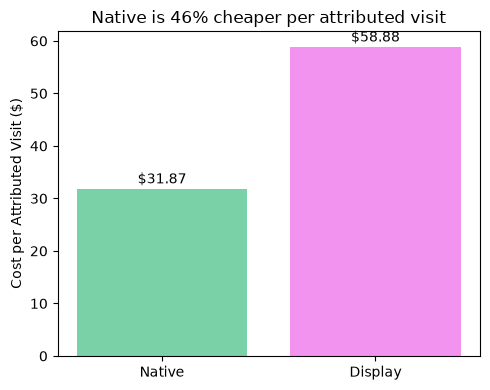

In [607]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(efficiency_by_channel["Channel Type"], efficiency_by_channel["Cost_per_Attributed_Visit"],
       color=["#7AD1A7", "#F293F0"])
ax.set_ylabel("Cost per Attributed Visit ($)")
ax.set_title("Native is 46% cheaper per attributed visit")
for i, v in enumerate(efficiency_by_channel["Cost_per_Attributed_Visit"]):
    ax.text(i, v + 1, f"${v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("../output_images/chart_channel_efficiency.png", dpi=150)
plt.show()

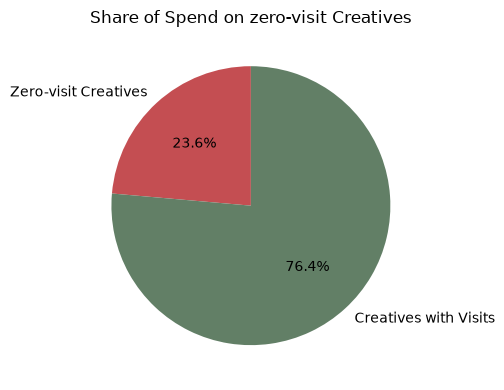

In [608]:
zero_visit_spend_pct = zero_visit_creatives["Media Cost"].sum() / campaign_metrics_with_fta["Media Cost"].sum() * 100
labels = ["Zero-visit Creatives", "Creatives with Visits"]
sizes = [zero_visit_spend_pct, 100 - zero_visit_spend_pct]

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(sizes, labels=labels, autopct="%1.1f%%", colors=["#C44E52", "#627F66"], startangle=90)
ax.set_title("Share of Spend on zero-visit Creatives")
plt.tight_layout()
plt.savefig("../output_images/chart_zero_visit_spend.png", dpi=150)
plt.show()

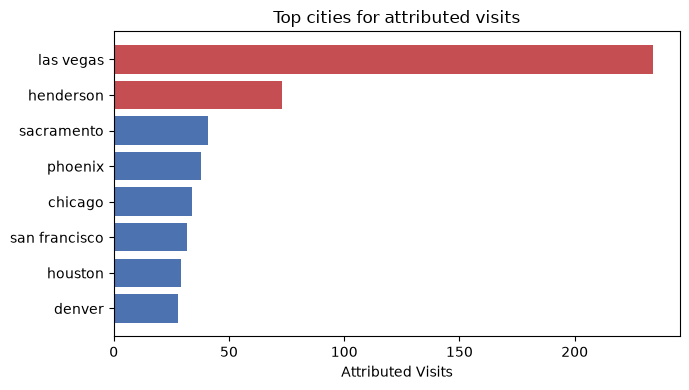

In [609]:
top_cities = visitationFTA["Origin_City"].value_counts().head(8)
colors = ["#C44E52" if city in ["las vegas", "henderson"] else "#4C72B0" for city in top_cities.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_cities.index[::-1], top_cities.values[::-1], color=colors[::-1])
ax.set_xlabel("Attributed Visits")
ax.set_title("Top cities for attributed visits")
plt.tight_layout()
plt.savefig("../output_images/chart_top_cities.png", dpi=150)
plt.show()